# EDA
- Items:
1. Начало данных: 2015-05-03, конец: 2015-09-13
2. В таблице item_properties можно проследить, что у 6% товаров есть несколько записей о категориях, вероятнее всего они принадлежат нескольким категориям сразу.
3. У категорий айтемов достаточно сложная система. В отдельной таблице можно пройти от подкатегории товара до общей категории. Если использовать контентную матрицу на основе категорий, то необходимо выбрать подход: подкатегории или общие. При выборе подкатегорий рекомендации будут более точными, но некоторые товары с похожими категориями могут не быть отмечены. При выборе изначальных будет больше связей между товарыми, но рекомендации будут менее точными с связи с отсутствием подкатегорий.  
Поскольку для системы рекомендаций будет использоваться двухстадийный подход с признаками, имеет смысл выбрать подкатегории.
- Events:
1. Начало данных: 2015-05-03, конец: 2015-09-18
2. В датасете есть очень большой дисбаланс типов интеракций: 97% просмотров, 2% добавлений в корзину, ~1% покупок. В связи с этим, построение als матрицы только на основе таргета невозможно. 
3. В датасете присутствует слабая корреляция кол-ва просмотров с добавлениями в корзину. На основе этого можно использовать просмотр как слабый вес (0.3) при построении матрицы als с добавлением в корзину (1.0).
4. Несмотря на то, что количество событий заметно падает после июля, их все равно остается достаточное количество в каждем месяце для корректного разделения данных.  
Также распределения таргета по всем месяцам равномерно и соотвествует остальным событиям.
# Обработка данных:
- объединение item_properties в один df
- замена timestamp на формат даты
- создание отдельного df с айтемами и их категориями

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## item_properties

In [7]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# трансформация даты
item_properties_part1 = pd.read_csv('item_properties_part1.csv')
item_properties_part1['date'] = pd.to_datetime(item_properties_part1['timestamp'], unit='ms')
item_properties_part2 = pd.read_csv('item_properties_part2.csv')
item_properties_part2['date'] = pd.to_datetime(item_properties_part2['timestamp'], unit='ms')

# объединения датафреймов
item_properties = pd.concat([item_properties_part1, item_properties_part2]).drop(columns=['timestamp'])

In [12]:
# айтемы с несколькими категориями и общее кол-во айтемов

df_cat = item_properties[item_properties['property'] == 'categoryid']
df_cat = df_cat.groupby('itemid').count()
df_cat = df_cat[df_cat['property'] > 1]

all_items = item_properties['itemid'].nunique()

print(f'Общее кол-во айтемов: {all_items}')
print(f'Айтемы с несколькими категориями: {len(df_cat)}')

Общее кол-во айтемов: 417053
Айтемы с несколькими категориями: 23352


<Axes: title={'center': 'Самые популярные категории'}, xlabel='category', ylabel='count'>

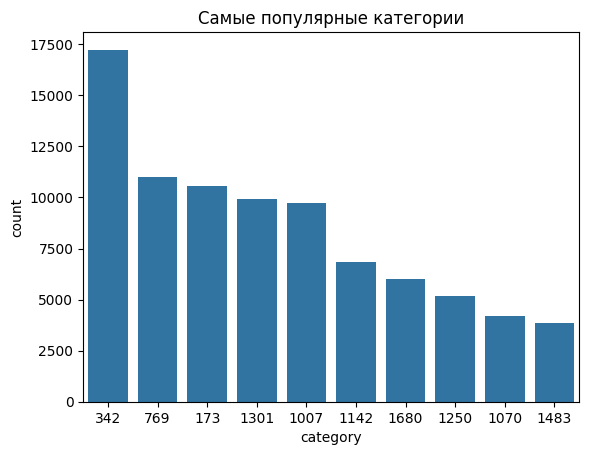

In [14]:
# самые популярные категории
import seaborn as sns
import matplotlib.pyplot as plt

item_categories = item_properties[item_properties['property'] == 'categoryid'].sort_values('date').drop(columns=['property'])
item_categories = item_categories.groupby('itemid')['value'].last().reset_index(name='category')
genre_count = item_categories.value_counts('category').reset_index(name='count')[:10]

fig1, ax = plt.subplots()
ax.set_title('Самые популярные категории')
sns.barplot(
    data=genre_count,
    x='category',
    y='count'
)

## events

In [1]:
import pandas as pd

events = pd.read_csv('events.csv')
events['date'] = pd.to_datetime(events['timestamp'], unit='ms')
events = events.drop(columns=['timestamp'])

<Axes: title={'center': 'Распределение типов интеракций'}, xlabel='event', ylabel='count'>

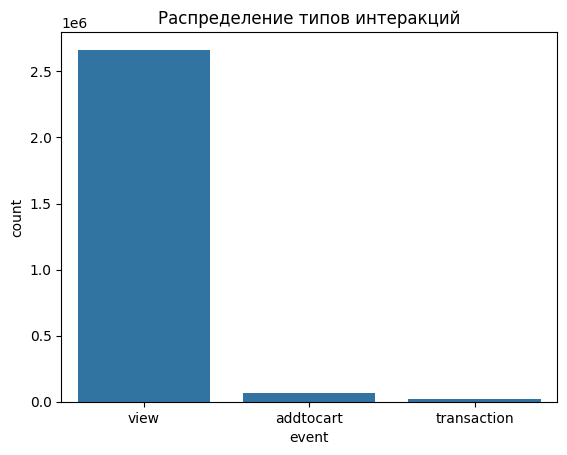

In [15]:
# распределение типов интеракций
import seaborn as sns
import matplotlib.pyplot as plt

df_agg = events['event'].value_counts().reset_index(name='count')

fig2, ax = plt.subplots()
ax.set_title('Распределение типов интеракций')
sns.barplot(
    data=df_agg,
    x='event',
    y='count'
)

In [ ]:
# кол-во юзеров с добавлением в корзину

un = events[events['event'] == 'addtocart']
un['visitorid'].nunique()

37722

In [ ]:
# кол-во айтемов с добавлением в корзину

un = events[events['event'] == 'addtocart']
un['itemid'].nunique()

23903

In [ ]:
# общее кол-во юзеров

events['visitorid'].nunique()

1407580

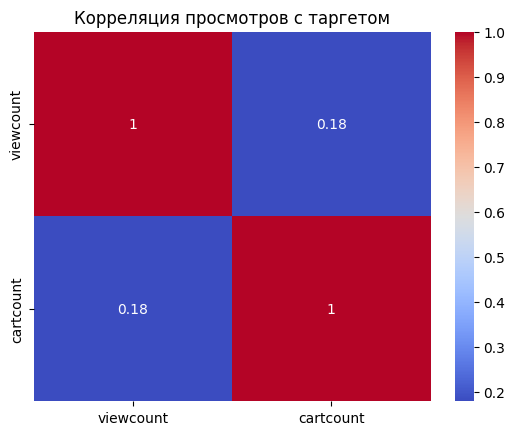

In [16]:
#корреляция просмотров с таргетом

import seaborn as sns
import matplotlib.pyplot as plt

viewcount = events[events['event'] == 'view']
viewcount = viewcount.groupby('visitorid')['itemid'].value_counts().reset_index(name='viewcount')

cartcount = events[events['event'] == 'addtocart']
cartcount = cartcount.groupby('visitorid')['itemid'].value_counts().reset_index(name='cartcount')

oor = pd.merge(viewcount, cartcount[['visitorid', 'itemid', 'cartcount']], how='left', on=['visitorid', 'itemid'])
oor[['viewcount', 'cartcount']] = oor[['viewcount', 'cartcount']].fillna(0)
correlation = oor['viewcount'].corr(oor['cartcount'], method='spearman')

fig3, ax = plt.subplots()
ax.set_title('Корреляция просмотров с таргетом')
sns.heatmap(oor[['viewcount', 'cartcount']].corr(method='spearman'), annot=True, cmap='coolwarm')
plt.show()

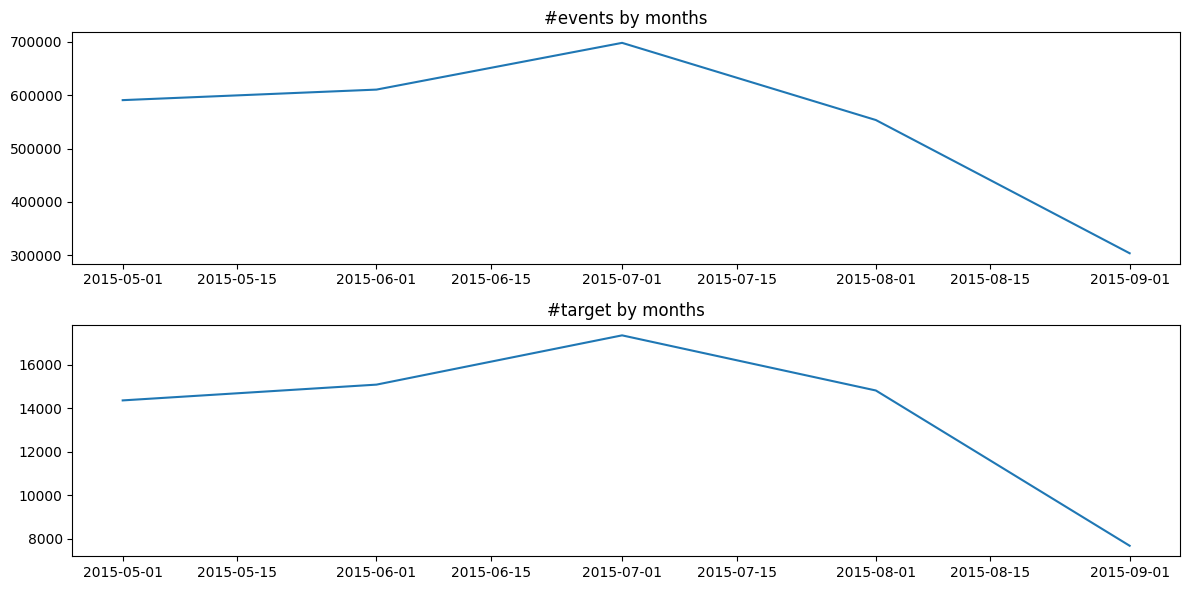

In [6]:
# события по месяцам

from pandas.tseries.offsets import MonthEnd
import seaborn as sns
import matplotlib.pyplot as plt

events["started_at_month"] = pd.to_datetime(events["date"]).dt.to_period('M').dt.to_timestamp().dt.date
interactions_by_month = events.groupby("started_at_month").agg(events=("date", "count")).reset_index()

addtocart_events = events[events['event'] == 'addtocart']
target_by_month = addtocart_events.groupby("started_at_month").agg(events=("date", "count")).reset_index()

fig4, ax = plt.subplots(2, 1, figsize=(12, 6))

ax[0].plot(interactions_by_month["started_at_month"], interactions_by_month["events"])
ax[0].set_title("#events by months")

ax[1].plot(target_by_month["started_at_month"], target_by_month["events"])
ax[1].set_title("#target by months")

plt.tight_layout()
plt.show()

In [9]:
interactions_by_month

,started_at_month,events
0,2015-05-01,590652
1,2015-06-01,610393
2,2015-07-01,697984
3,2015-08-01,553362
4,2015-09-01,303710


# Логирование

In [18]:
import mlflow
import os
from dotenv import load_dotenv

load_dotenv()

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = 'FINAL_PROJECT'

os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

if mlflow.get_experiment_by_name(name=EXPERIMENT_NAME):
    experiment_id = dict(mlflow.get_experiment_by_name(name=EXPERIMENT_NAME))['experiment_id']
    mlflow.set_experiment(experiment_id=experiment_id)
else:
    mlflow.set_experiment(EXPERIMENT_NAME)
    experiment_id = dict(mlflow.get_experiment_by_name(name=EXPERIMENT_NAME))['experiment_id']
    mlflow.set_experiment(experiment_id=experiment_id)

with mlflow.start_run(run_name='eda', experiment_id=experiment_id) as run:
    mlflow.log_figure(fig1, 'popular_categories.png')
    mlflow.log_figure(fig2, 'interaction_types_spread.png')
    mlflow.log_figure(fig3, 'views_target_correlation.png')
    mlflow.log_figure(fig4, 'events_by_months.png')

🏃 View run eda at: http://127.0.0.1:5000/#/experiments/12/runs/e66bc07add6844689dbca130ef9a5bd5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/12
